In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [50]:
sns.set_style("darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.dpi"]       = 130
plt.rcParams["figure.figsize"]   = (12, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"]   = 11

In [95]:
CYAN  = "#00e5ff"
RED   = "#ff4d6d"
GREEN = "#00f5a0"
AMBER = "#ffb347"
 
print("Libraries loaded")

Libraries loaded


In [97]:
df = pd.read_csv(r"C:\Users\mukul\Desktop\Projects\patient-readmission-prediction\data\processed\indian_patient_data.csv")
df["admission_date"] = pd.to_datetime(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])

In [98]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Shape             : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range        : {df['admission_date'].min().date()} → {df['admission_date'].max().date()}")
print(f"  States covered    : {df['state'].nunique()}")
print(f"  Unique diagnoses  : {df['diagnosis'].nunique()}")
print(f"  Readmission rate  : {df['readmitted_30_days'].mean():.1%}")
print(f"  Avg age           : {df['age'].mean():.1f} years")
print(f"  Avg stay          : {df['length_of_stay_days'].mean():.1f} days")
print(f"  Avg medications   : {df['num_medications'].mean():.1f}")
print("=" * 60)
 
df.head()

DATASET OVERVIEW
  Shape             : 10,000 rows × 23 columns
  Date range        : 2020-01-01 → 2024-12-31
  States covered    : 14
  Unique diagnoses  : 15
  Readmission rate  : 32.2%
  Avg age           : 52.2 years
  Avg stay          : 4.7 days
  Avg medications   : 6.5


,patient_id,name,age,gender,state,city,diagnosis,department,admission_date,discharge_date,...,num_previous_admissions,num_medications,medications_prescribed,hba1c,blood_glucose_mg_dl,systolic_bp_mmhg,creatinine_mg_dl,haemoglobin_g_dl,total_charges_inr,readmitted_30_days
0,PTIND00001,Rajesh Das,26,Male,Tamil Nadu,Coimbatore,Hypertension,Emergency,2020-06-27,2020-06-29,...,3,1,Metformin,6.1,101,134,0.5,12.0,30318,0
1,PTIND00002,Shobha Nair,65,Female,Haryana,Faridabad,COPD,Pulmonology,2020-11-14,2020-11-20,...,1,2,"Insulin, Ramipril",4.0,119,147,0.4,10.8,82970,0
2,PTIND00003,Kiran Chauhan,27,Female,Odisha,Sambalpur,Dengue Fever,Nephrology,2023-12-13,2023-12-14,...,0,11,"Atenolol, Doxycycline, Atorvastatin, Insulin, ...",6.0,107,110,0.4,12.3,23416,0
3,PTIND00004,Deepak Chatterjee,30,Male,Karnataka,Belagavi,COPD,General Medicine,2021-04-14,2021-04-15,...,2,7,"Atorvastatin, Insulin, Atenolol, Pantoprazole,...",5.1,69,152,0.5,12.8,45809,1
4,PTIND00005,Meena Mehta,77,Female,Gujarat,Surat,Tuberculosis,Cardiology,2024-03-27,2024-03-31,...,1,3,"Azithromycin, Amlodipine, Doxycycline",4.9,77,105,1.3,11.4,31880,0


In [99]:
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
patient_id                         object
name                               object
age                                 int64
gender                             object
state                              object
city                               object
diagnosis                          object
department                         object
admission_date             datetime64[ns]
discharge_date             datetime64[ns]
length_of_stay_days                 int64
discharge_type                     object
insurance_type                     object
num_previous_admissions             int64
num_medications                     int64
medications_prescribed             object
hba1c                             float64
blood_glucose_mg_dl                 int64
systolic_bp_mmhg                    int64
creatinine_mg_dl                  float64
haemoglobin_g_dl                  float64
total_charges_inr                   int64
readmitted_30_days                  int64
dtype: object


In [100]:
missing = df.isnull().sum()
print("Missing Values:")
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")

Missing Values:
✅ No missing values found!


In [101]:
dupes = df.duplicated(subset="patient_id").sum()
print(f"\nDuplicate patient IDs: {dupes}")


Duplicate patient IDs: 0


In [102]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
age,10000.0,52.1697,18.0,38.0,52.0,65.0,95.0,18.299847
admission_date,10000,2022-06-29 05:31:03.360000,2020-01-01 00:00:00,2021-03-22 18:00:00,2022-07-02 00:00:00,2023-09-30 00:00:00,2024-12-31 00:00:00,NaN
discharge_date,10000,2022-07-03 21:10:04.800000,2020-01-02 00:00:00,2021-03-27 00:00:00,2022-07-07 00:00:00,2023-10-06 00:00:00,2025-01-19 00:00:00,NaN
length_of_stay_days,10000.0,4.6521,1.0,1.0,3.0,6.0,45.0,4.744167
num_previous_admissions,10000.0,0.774,0.0,0.0,0.0,1.0,9.0,1.182313
num_medications,10000.0,6.4813,1.0,3.0,6.0,9.0,12.0,3.455466
hba1c,10000.0,5.70053,4.0,4.9,5.5,6.3,11.2,1.20068
blood_glucose_mg_dl,10000.0,103.3335,60.0,85.75,96.0,108.0,346.0,35.812036
systolic_bp_mmhg,10000.0,127.0704,80.0,112.0,127.0,141.0,220.0,21.03707
creatinine_mg_dl,10000.0,1.04204,0.4,0.6,0.9,1.3,3.9,0.585642


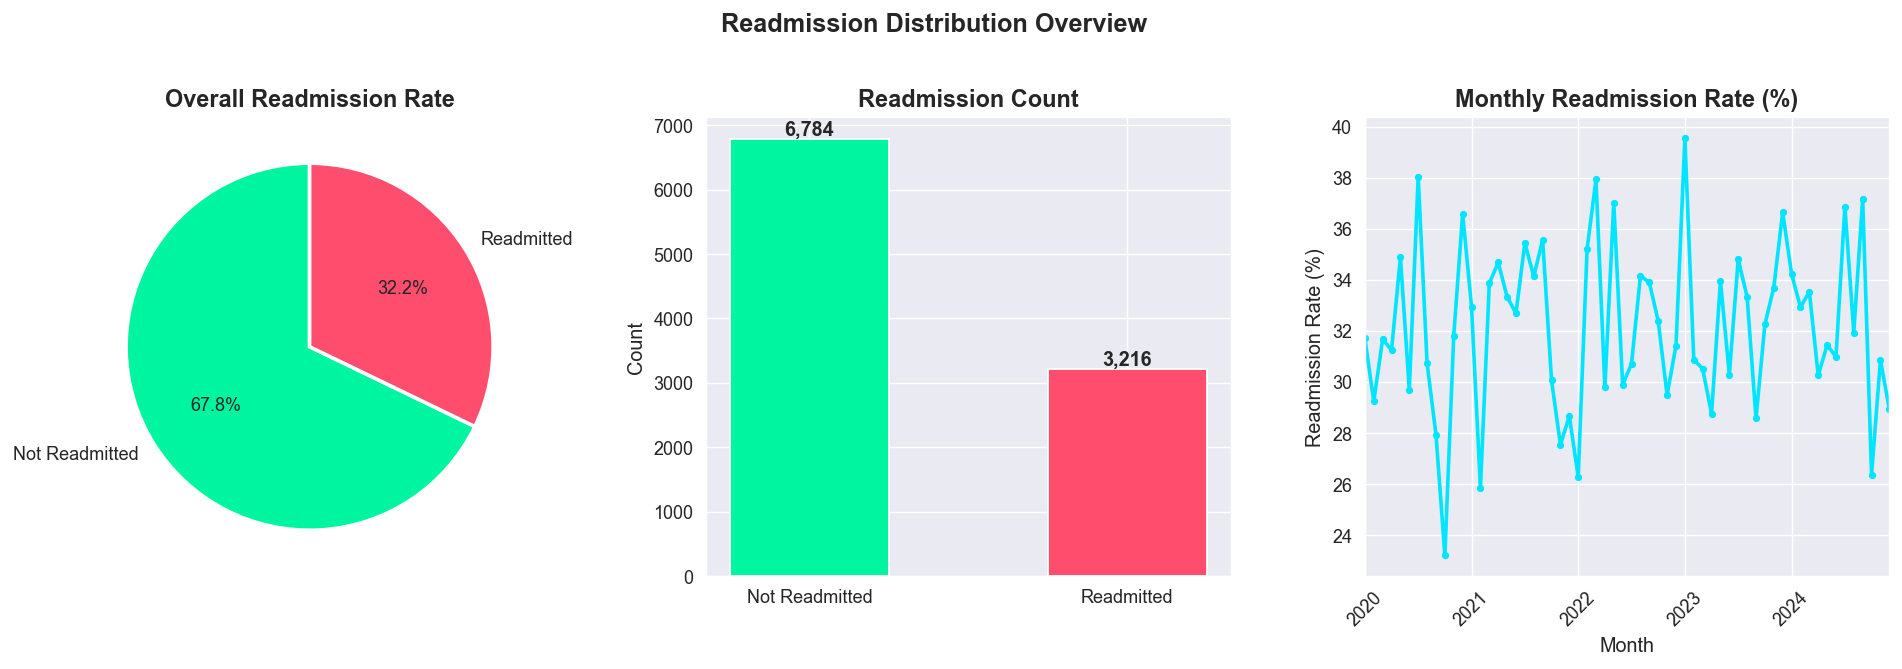

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie
counts = df["readmitted_30_days"].value_counts()
axes[0].pie(counts, labels=["Not Readmitted", "Readmitted"],
            colors=[GREEN, RED], autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Overall Readmission Rate")

# Bar
bars = axes[1].bar(["Not Readmitted", "Readmitted"], counts.values,
                   color=[GREEN, RED], edgecolor="white", width=0.5)
axes[1].set_title("Readmission Count")
axes[1].set_ylabel("Count")
for bar in bars:
    axes[1].annotate(f"{int(bar.get_height()):,}",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=11, fontweight="bold")

# Monthly trend
df["month"] = df["admission_date"].dt.to_period("M")
monthly = df.groupby("month")["readmitted_30_days"].mean() * 100
monthly.plot(ax=axes[2], color=CYAN, linewidth=2, marker="o", markersize=3)
axes[2].set_title("Monthly Readmission Rate (%)")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Readmission Rate (%)")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Readmission Distribution Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "01_readmission_distribution.png"), bbox_inches="tight")
plt.show()

In [104]:
import os

BASE = r"c:\Users\mukul\Desktop\Projects\patient-readmission-prediction"

# Create all required folders
os.makedirs(os.path.join(BASE, "reports"), exist_ok=True)
os.makedirs(os.path.join(BASE, "data", "processed"), exist_ok=True)
os.makedirs(os.path.join(BASE, "models"), exist_ok=True)

print("All folders created")

All folders created


In [105]:
plt.suptitle("Readmission Distribution Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"c:\Users\mukul\Desktop\Projects\patient-readmission-prediction\reports\01_readmission_distribution.png", bbox_inches="tight")
plt.show()
 

<Figure size 1560x650 with 0 Axes>

In [64]:
print(f"\nReadmission Rate  : {df['readmitted_30_days'].mean():.1%}")
print(f"Not Readmitted    : {(df['readmitted_30_days']==0).sum():,} patients")
print(f"Readmitted        : {(df['readmitted_30_days']==1).sum():,} patients")


Readmission Rate  : 32.2%
Not Readmitted    : 6,784 patients
Readmitted        : 3,216 patients


In [71]:
import os

BASE    = r"c:\Users\mukul\Desktop\Projects\patient-readmission-prediction"
REPORTS = os.path.join(BASE, "reports")

os.makedirs(REPORTS, exist_ok=True)

print(f"Reports folder: {REPORTS} ✅")

Reports folder: c:\Users\mukul\Desktop\Projects\patient-readmission-prediction\reports ✅


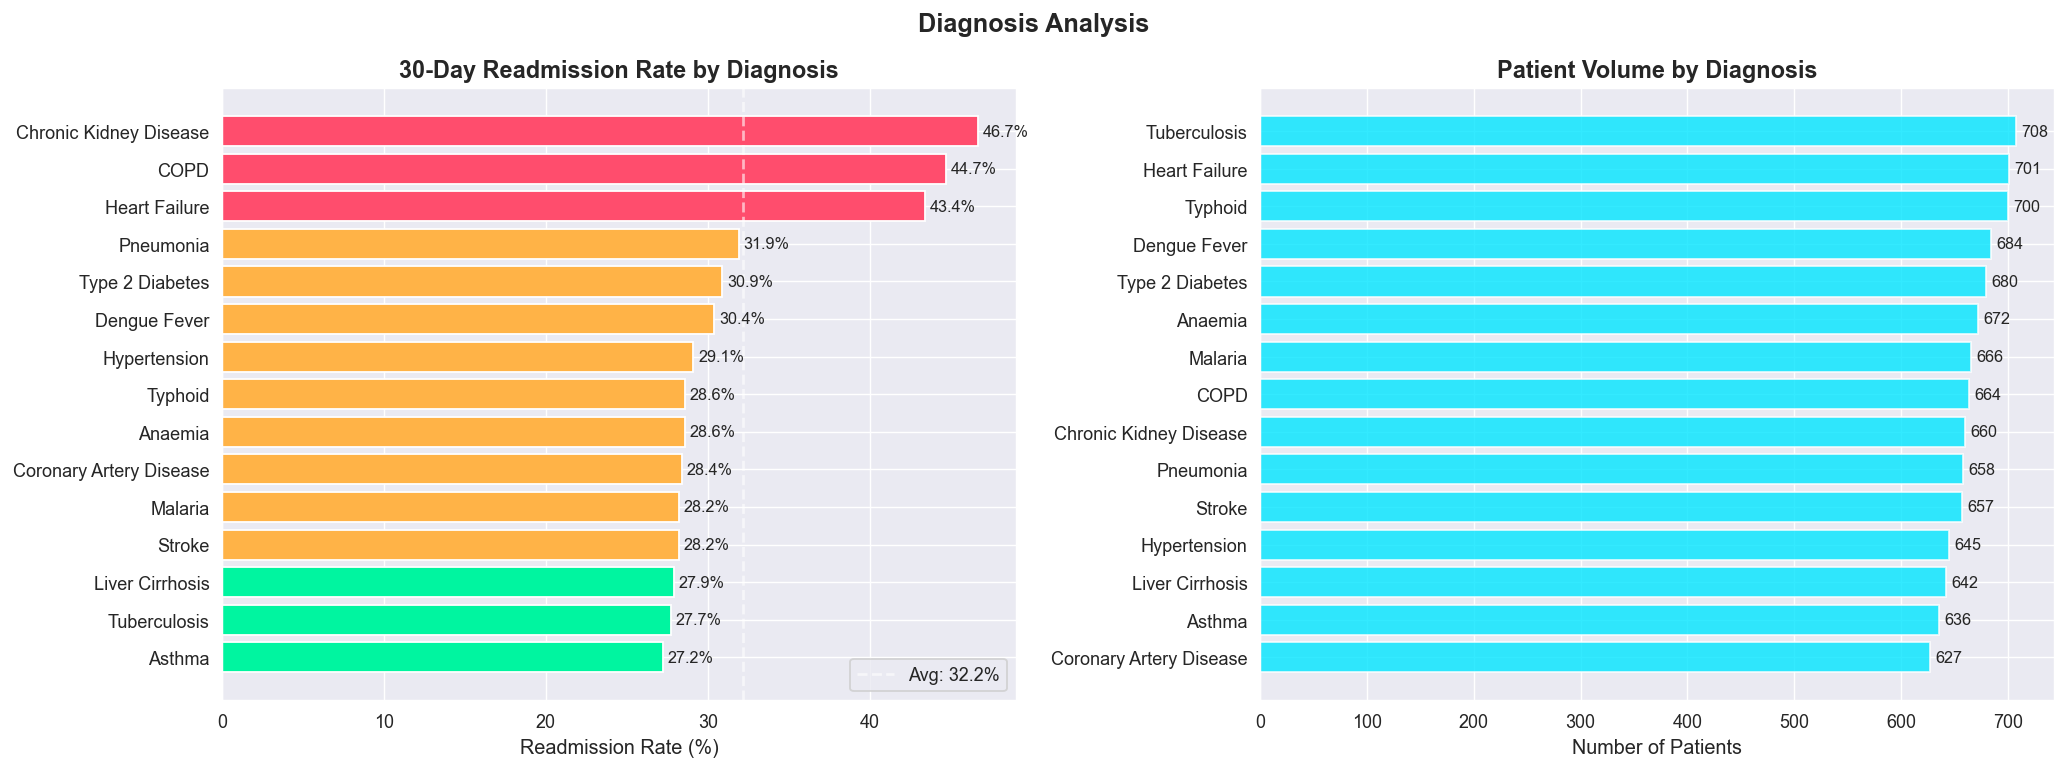

In [72]:
diag_stats = df.groupby("diagnosis").agg(
    total      = ("readmitted_30_days", "count"),
    readmitted = ("readmitted_30_days", "sum")
).reset_index()
diag_stats["rate"] = (diag_stats["readmitted"] / diag_stats["total"] * 100).round(1)
diag_stats = diag_stats.sort_values("rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = [RED if r > 35 else AMBER if r > 28 else GREEN for r in diag_stats["rate"]]
bars = axes[0].barh(diag_stats["diagnosis"], diag_stats["rate"],
                    color=colors, edgecolor="white")
axes[0].set_xlabel("Readmission Rate (%)")
axes[0].set_title("30-Day Readmission Rate by Diagnosis")
axes[0].axvline(df["readmitted_30_days"].mean()*100, color="white",
                linestyle="--", alpha=0.6, label=f"Avg: {df['readmitted_30_days'].mean()*100:.1f}%")
axes[0].legend()
for bar, val in zip(bars, diag_stats["rate"]):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9)

diag_vol = df["diagnosis"].value_counts().sort_values(ascending=True)
axes[1].barh(diag_vol.index, diag_vol.values, color=CYAN, edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Number of Patients")
axes[1].set_title("Patient Volume by Diagnosis")
for i, val in enumerate(diag_vol.values):
    axes[1].text(val + 5, i, f"{val:,}", va="center", fontsize=9)

plt.suptitle("Diagnosis Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "02_diagnosis_analysis.png"), bbox_inches="tight")
plt.show()

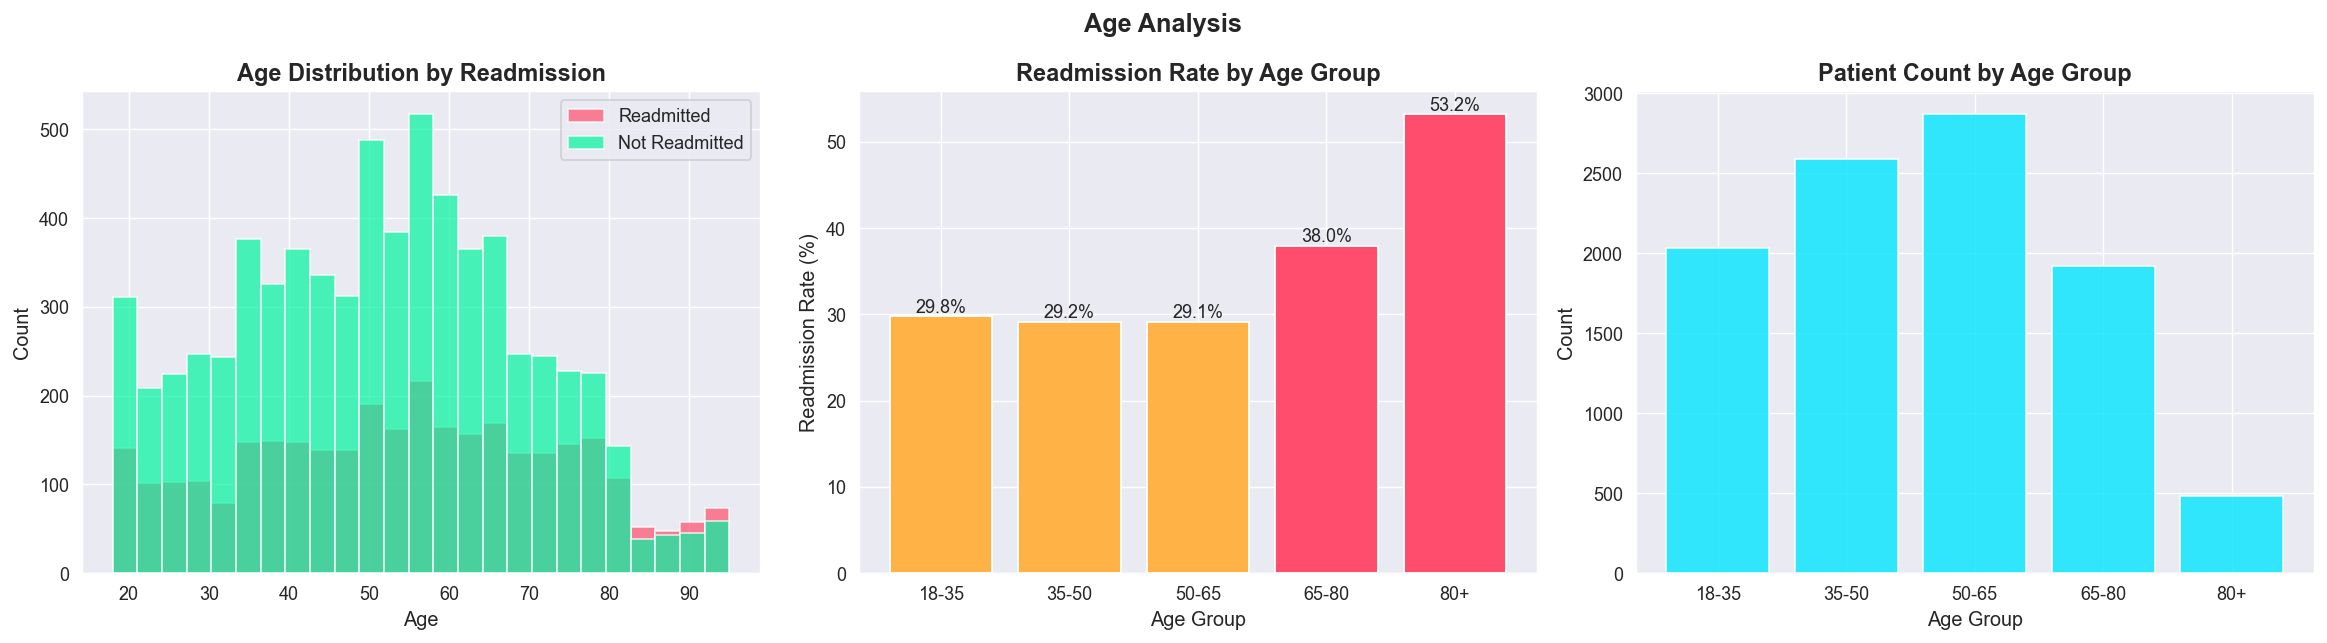


Readmission Rate by Age Group:
  18-35: 29.8%
  35-50: 29.2%
  50-65: 29.1%
  65-80: 38.0%
  80+: 53.2%


In [84]:
df["age_group"] = pd.cut(df["age"], bins=[18,35,50,65,80,95],
                          labels=["18-35","35-50","50-65","65-80","80+"])
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Age distribution
axes[0].hist(df[df["readmitted_30_days"]==1]["age"], bins=25,
             alpha=0.7, color=RED, label="Readmitted", edgecolor="white")
axes[0].hist(df[df["readmitted_30_days"]==0]["age"], bins=25,
             alpha=0.7, color=GREEN, label="Not Readmitted", edgecolor="white")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution by Readmission")
axes[0].legend()
 
# Readmission rate by age group
age_rate = df.groupby("age_group", observed=True)["readmitted_30_days"].mean() * 100
bars = axes[1].bar(age_rate.index, age_rate.values,
                   color=[RED if v > 35 else AMBER if v > 28 else GREEN for v in age_rate.values],
                   edgecolor="white")
axes[1].set_title("Readmission Rate by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Readmission Rate (%)")
for bar in bars:
    axes[1].annotate(f"{bar.get_height():.1f}%",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)
 
# Patient count by age group
age_count = df["age_group"].value_counts().sort_index()
axes[2].bar(age_count.index, age_count.values, color=CYAN, edgecolor="white", alpha=0.8)
axes[2].set_title("Patient Count by Age Group")
axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Count")
 
plt.suptitle("Age Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "03_age_analysis.png"), bbox_inches="tight")
plt.show()
 
print("\nReadmission Rate by Age Group:")
for group, rate in age_rate.items():
    print(f"  {group}: {rate:.1f}%")

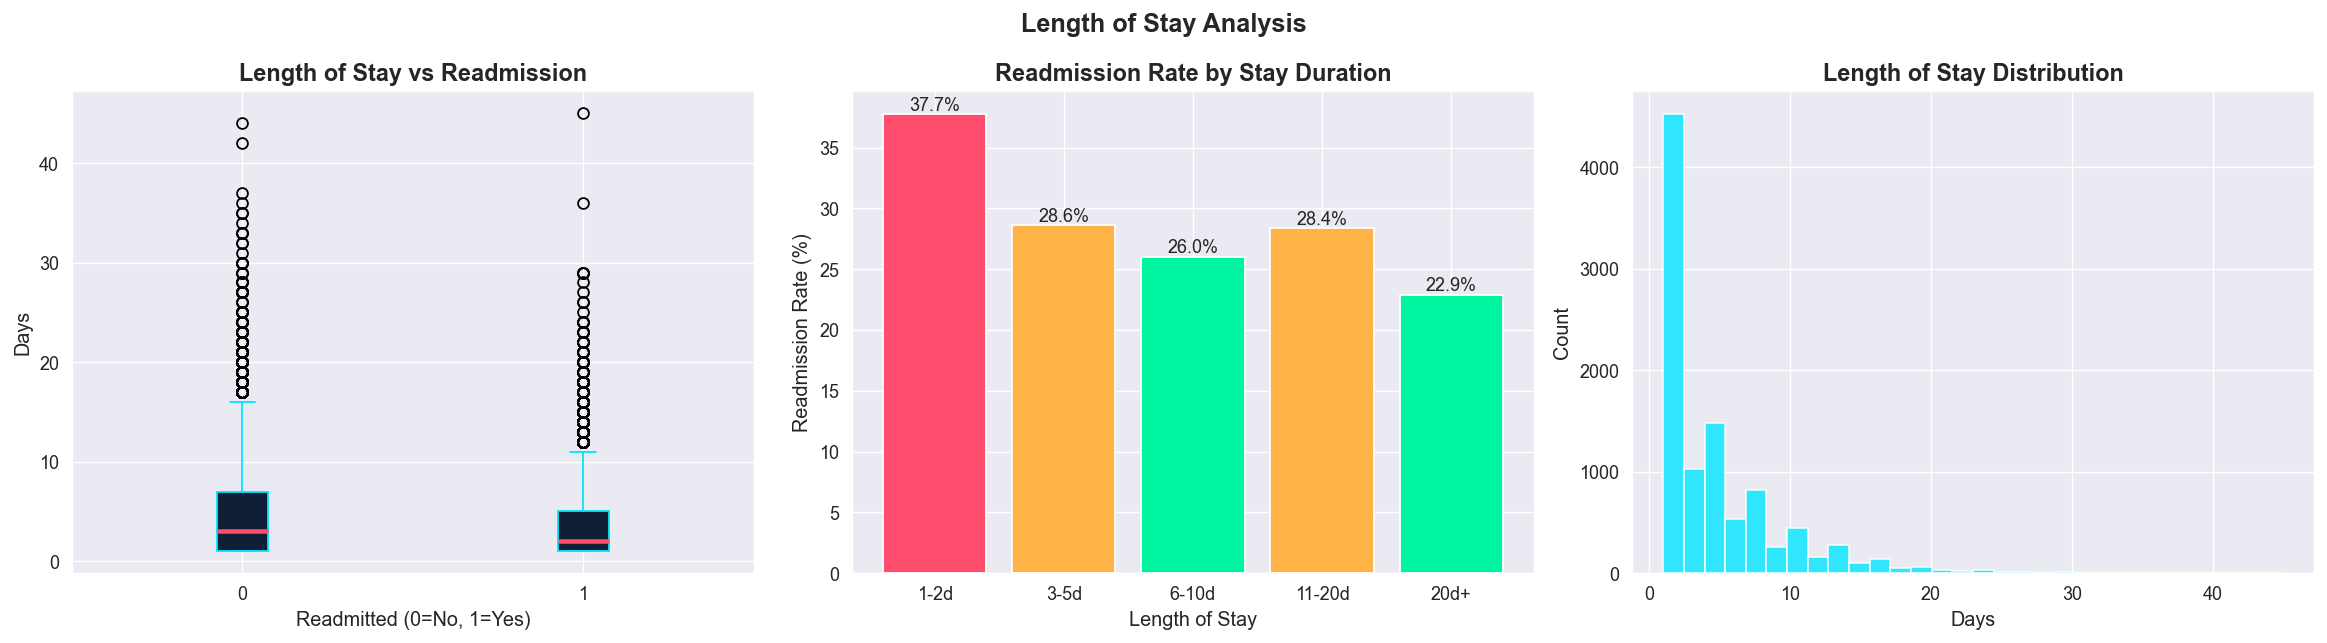


Avg stay (readmitted)    : 4.1 days
Avg stay (not readmitted): 4.9 days


In [85]:
df["stay_bucket"] = pd.cut(df["length_of_stay_days"], bins=[0,2,5,10,20,45],
                            labels=["1-2d","3-5d","6-10d","11-20d","20d+"])
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Box plot
df.boxplot(column="length_of_stay_days", by="readmitted_30_days",
           ax=axes[0], patch_artist=True,
           boxprops=dict(facecolor="#0f1f35", color=CYAN),
           medianprops=dict(color=RED, linewidth=2.5),
           whiskerprops=dict(color=CYAN),
           capprops=dict(color=CYAN))
axes[0].set_title("Length of Stay vs Readmission")
axes[0].set_xlabel("Readmitted (0=No, 1=Yes)")
axes[0].set_ylabel("Days")
plt.sca(axes[0])
plt.title("Length of Stay vs Readmission")
 
# Stay bucket readmission rate
stay_rate = df.groupby("stay_bucket", observed=True)["readmitted_30_days"].mean() * 100
bars = axes[1].bar(stay_rate.index, stay_rate.values,
                   color=[RED if v > 35 else AMBER if v > 28 else GREEN for v in stay_rate.values],
                   edgecolor="white")
axes[1].set_title("Readmission Rate by Stay Duration")
axes[1].set_xlabel("Length of Stay")
axes[1].set_ylabel("Readmission Rate (%)")
for bar in bars:
    axes[1].annotate(f"{bar.get_height():.1f}%",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)
 
# Stay distribution
axes[2].hist(df["length_of_stay_days"], bins=30,
             color=CYAN, edgecolor="white", alpha=0.8)
axes[2].set_title("Length of Stay Distribution")
axes[2].set_xlabel("Days")
axes[2].set_ylabel("Count")
 
plt.suptitle("Length of Stay Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "04_stay_analysis.png"), bbox_inches="tight")
plt.show()
 
print(f"\nAvg stay (readmitted)    : {df[df['readmitted_30_days']==1]['length_of_stay_days'].mean():.1f} days")
print(f"Avg stay (not readmitted): {df[df['readmitted_30_days']==0]['length_of_stay_days'].mean():.1f} days")

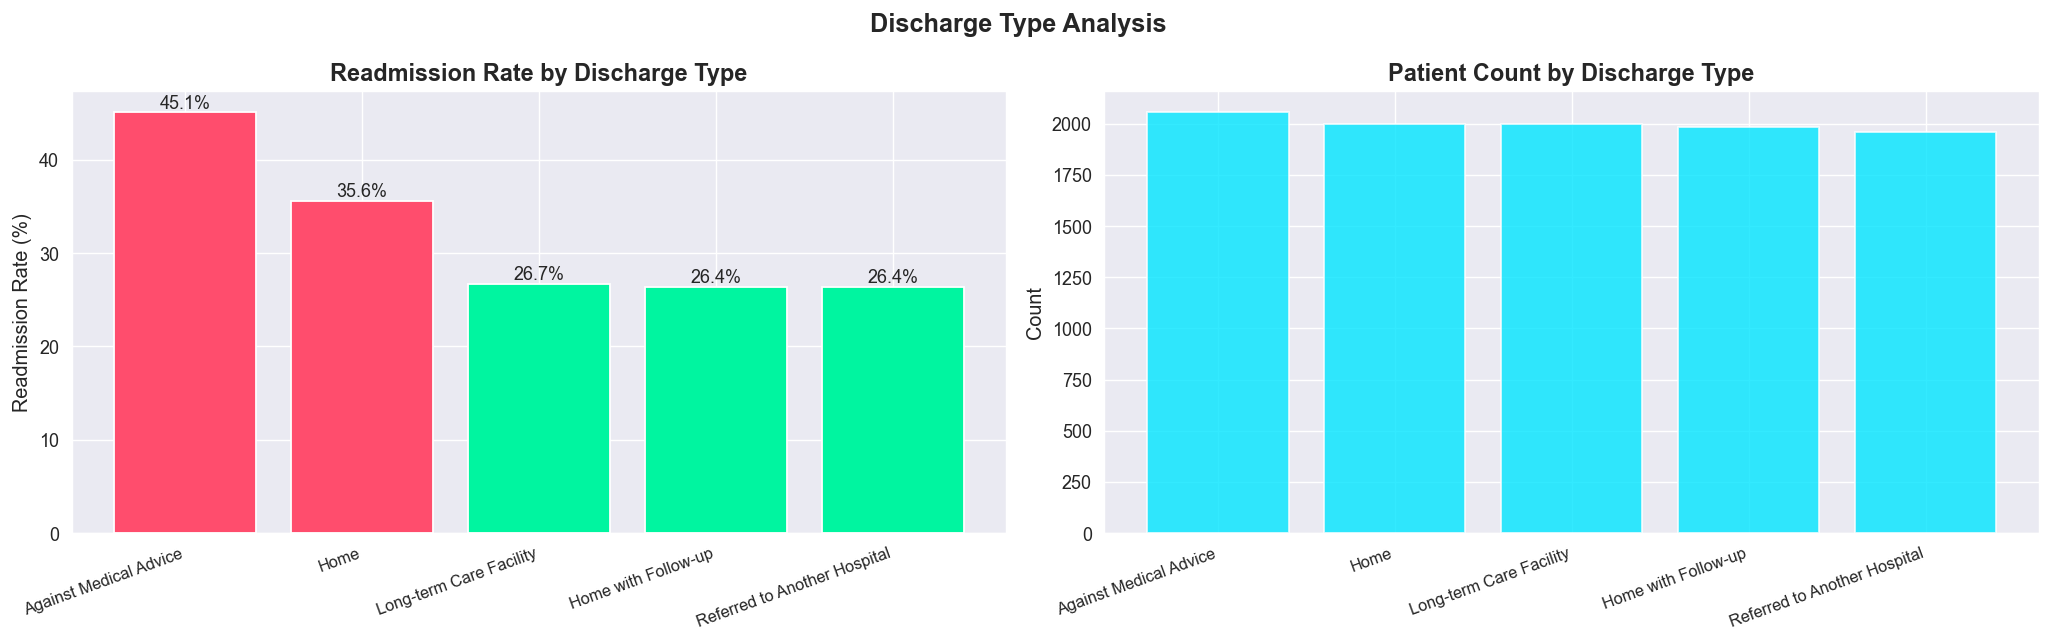


Readmission by Discharge Type:
              discharge_type  total  readmitted  rate
      Against Medical Advice   2056         928  45.1
                        Home   1999         712  35.6
     Long-term Care Facility   2000         534  26.7
         Home with Follow-up   1985         524  26.4
Referred to Another Hospital   1960         518  26.4


In [86]:
discharge_stats = df.groupby("discharge_type").agg(
    total      = ("readmitted_30_days", "count"),
    readmitted = ("readmitted_30_days", "sum")
).reset_index()
discharge_stats["rate"] = (discharge_stats["readmitted"] / discharge_stats["total"] * 100).round(1)
discharge_stats = discharge_stats.sort_values("rate", ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
colors = [RED if r > 35 else AMBER if r > 28 else GREEN for r in discharge_stats["rate"]]
bars = axes[0].bar(range(len(discharge_stats)), discharge_stats["rate"],
                   color=colors, edgecolor="white")
axes[0].set_xticks(range(len(discharge_stats)))
axes[0].set_xticklabels(discharge_stats["discharge_type"], rotation=20, ha="right", fontsize=9)
axes[0].set_title("Readmission Rate by Discharge Type")
axes[0].set_ylabel("Readmission Rate (%)")
for bar in bars:
    axes[0].annotate(f"{bar.get_height():.1f}%",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)
 
axes[1].bar(range(len(discharge_stats)), discharge_stats["total"],
            color=CYAN, edgecolor="white", alpha=0.8)
axes[1].set_xticks(range(len(discharge_stats)))
axes[1].set_xticklabels(discharge_stats["discharge_type"], rotation=20, ha="right", fontsize=9)
axes[1].set_title("Patient Count by Discharge Type")
axes[1].set_ylabel("Count")
 
plt.suptitle("Discharge Type Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "05_discharge_analysis.png"), bbox_inches="tight")
plt.show()
 
print("\nReadmission by Discharge Type:")
print(discharge_stats[["discharge_type","total","readmitted","rate"]].to_string(index=False))
 

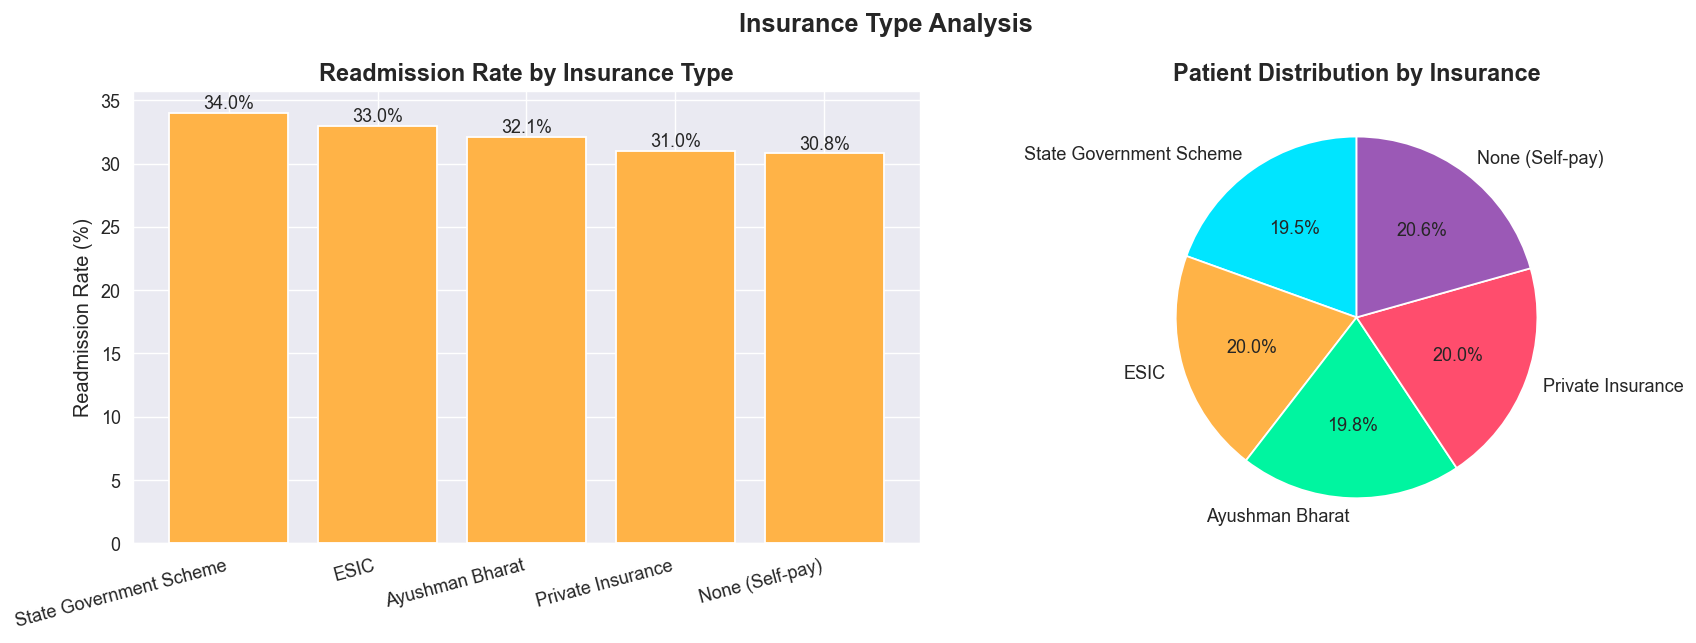

In [87]:
ins_stats = df.groupby("insurance_type").agg(
    total      = ("readmitted_30_days", "count"),
    readmitted = ("readmitted_30_days", "sum")
).reset_index()
ins_stats["rate"] = (ins_stats["readmitted"] / ins_stats["total"] * 100).round(1)
ins_stats = ins_stats.sort_values("rate", ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
colors = [RED if r > 35 else AMBER if r > 28 else GREEN for r in ins_stats["rate"]]
bars = axes[0].bar(ins_stats["insurance_type"], ins_stats["rate"],
                   color=colors, edgecolor="white")
axes[0].set_xticklabels(ins_stats["insurance_type"], rotation=15, ha="right")
axes[0].set_title("Readmission Rate by Insurance Type")
axes[0].set_ylabel("Readmission Rate (%)")
for bar in bars:
    axes[0].annotate(f"{bar.get_height():.1f}%",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)
 
axes[1].pie(ins_stats["total"], labels=ins_stats["insurance_type"],
            autopct="%1.1f%%", startangle=90,
            colors=[CYAN, AMBER, GREEN, RED, "#9b59b6"],
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Patient Distribution by Insurance")
 
plt.suptitle("Insurance Type Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "06_insurance_analysis.png"), bbox_inches="tight")
plt.show()
 

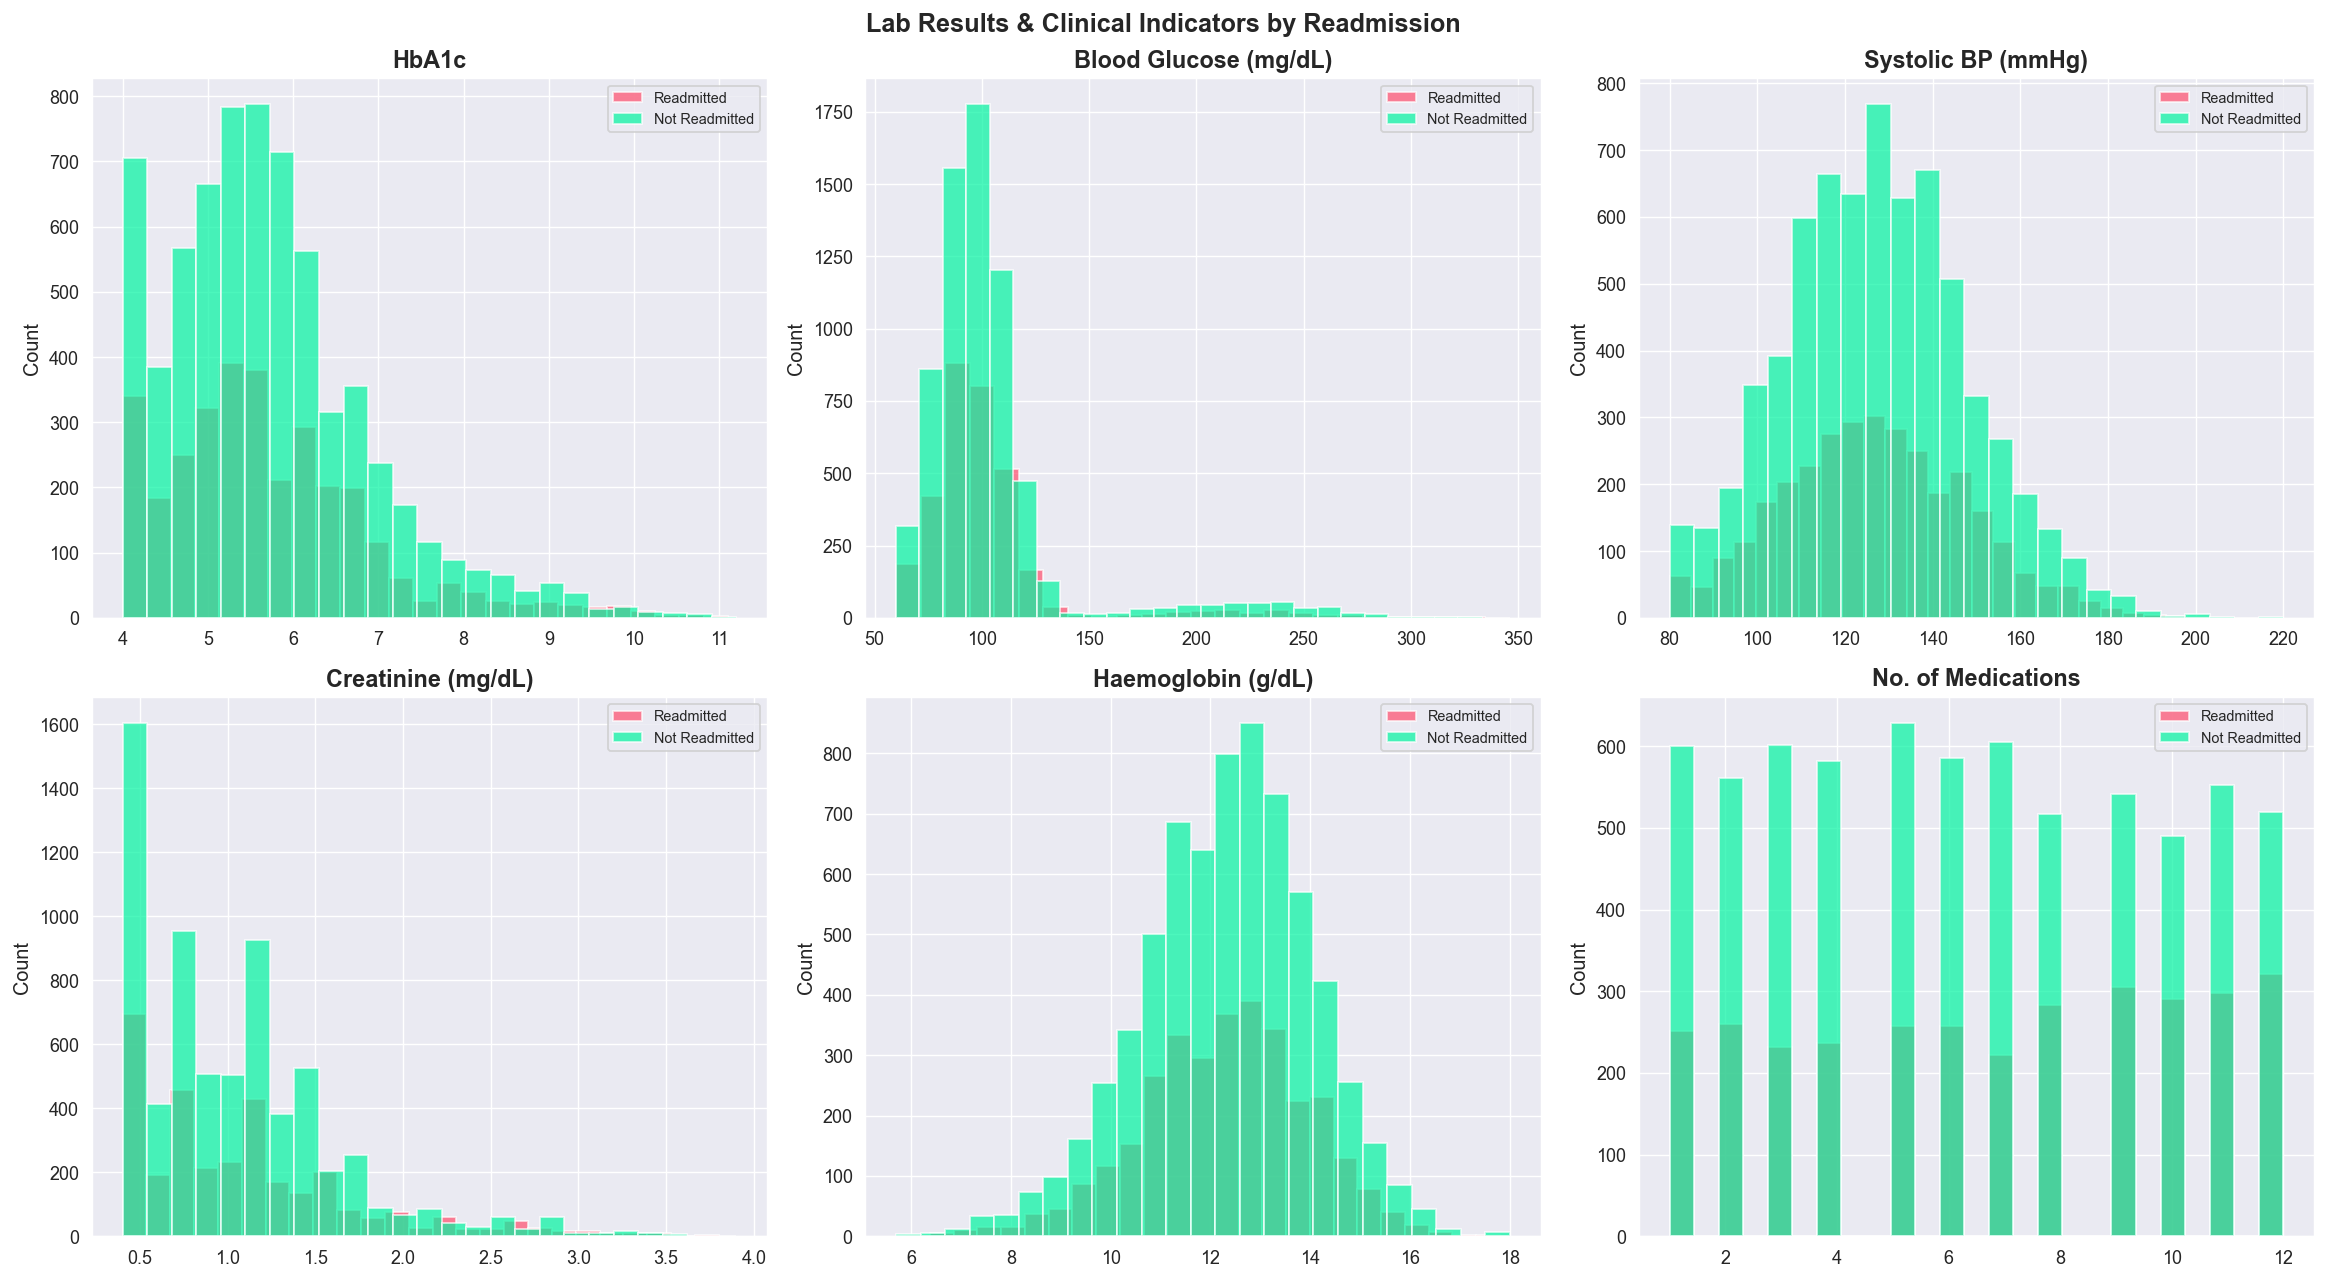


Diabetic patients — HbA1c > 9 readmission rate : 45.0%
Diabetic patients — HbA1c ≤ 9 readmission rate : 25.5%


In [88]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
 
lab_cols = ["hba1c", "blood_glucose_mg_dl", "systolic_bp_mmhg",
            "creatinine_mg_dl", "haemoglobin_g_dl", "num_medications"]
titles   = ["HbA1c", "Blood Glucose (mg/dL)", "Systolic BP (mmHg)",
            "Creatinine (mg/dL)", "Haemoglobin (g/dL)", "No. of Medications"]
 
for i, (col, title) in enumerate(zip(lab_cols, titles)):
    axes[i].hist(df[df["readmitted_30_days"]==1][col], bins=25,
                 alpha=0.7, color=RED, label="Readmitted", edgecolor="white")
    axes[i].hist(df[df["readmitted_30_days"]==0][col], bins=25,
                 alpha=0.7, color=GREEN, label="Not Readmitted", edgecolor="white")
    axes[i].set_title(title)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Count")
 
plt.suptitle("Lab Results & Clinical Indicators by Readmission", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "07_lab_results.png"), bbox_inches="tight")
plt.show()
 
# HbA1c threshold analysis for diabetic patients
diabetic = df[df["diagnosis"] == "Type 2 Diabetes"]
print(f"\nDiabetic patients — HbA1c > 9 readmission rate : {diabetic[diabetic['hba1c']>9]['readmitted_30_days'].mean():.1%}")
print(f"Diabetic patients — HbA1c ≤ 9 readmission rate : {diabetic[diabetic['hba1c']<=9]['readmitted_30_days'].mean():.1%}")
 

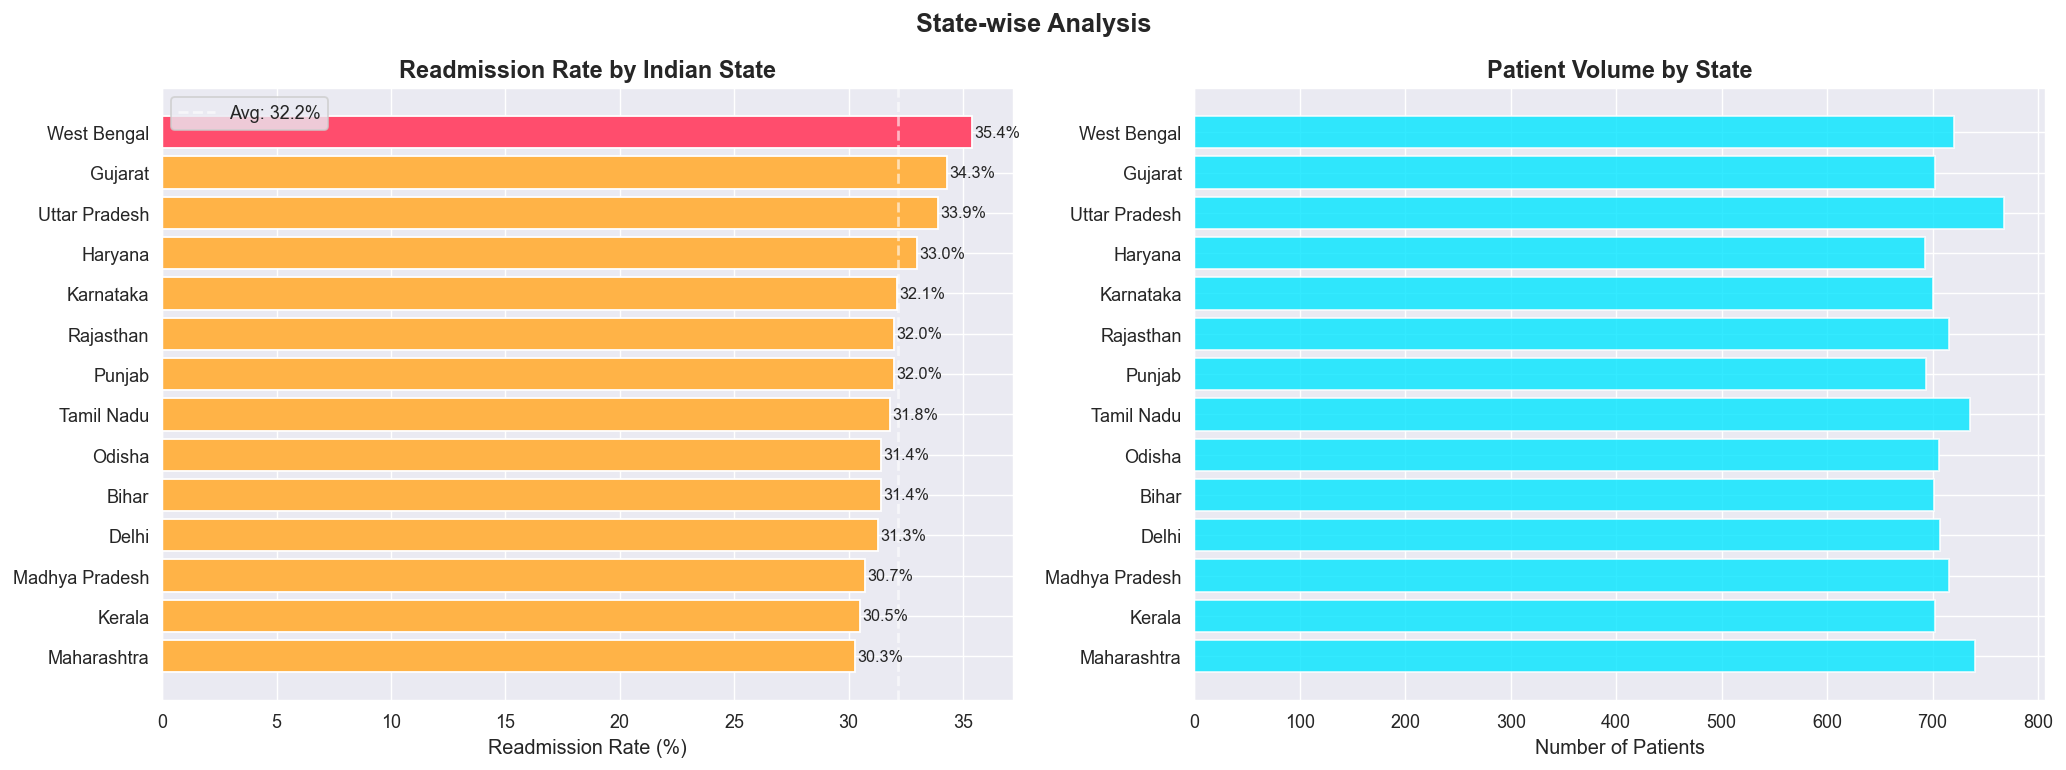

In [89]:
state_stats = df.groupby("state").agg(
    total      = ("readmitted_30_days", "count"),
    readmitted = ("readmitted_30_days", "sum")
).reset_index()
state_stats["rate"] = (state_stats["readmitted"] / state_stats["total"] * 100).round(1)
state_stats = state_stats.sort_values("rate", ascending=True)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
colors = [RED if r > 35 else AMBER if r > 28 else GREEN for r in state_stats["rate"]]
bars = axes[0].barh(state_stats["state"], state_stats["rate"],
                    color=colors, edgecolor="white")
axes[0].axvline(df["readmitted_30_days"].mean()*100, color="white",
                linestyle="--", alpha=0.6, label=f"Avg: {df['readmitted_30_days'].mean()*100:.1f}%")
axes[0].set_xlabel("Readmission Rate (%)")
axes[0].set_title("Readmission Rate by Indian State")
axes[0].legend()
for bar, val in zip(bars, state_stats["rate"]):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9)
 
axes[1].barh(state_stats["state"], state_stats["total"],
             color=CYAN, edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Number of Patients")
axes[1].set_title("Patient Volume by State")
 
plt.suptitle("State-wise Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "08_state_analysis.png"), bbox_inches="tight")
plt.show()
 

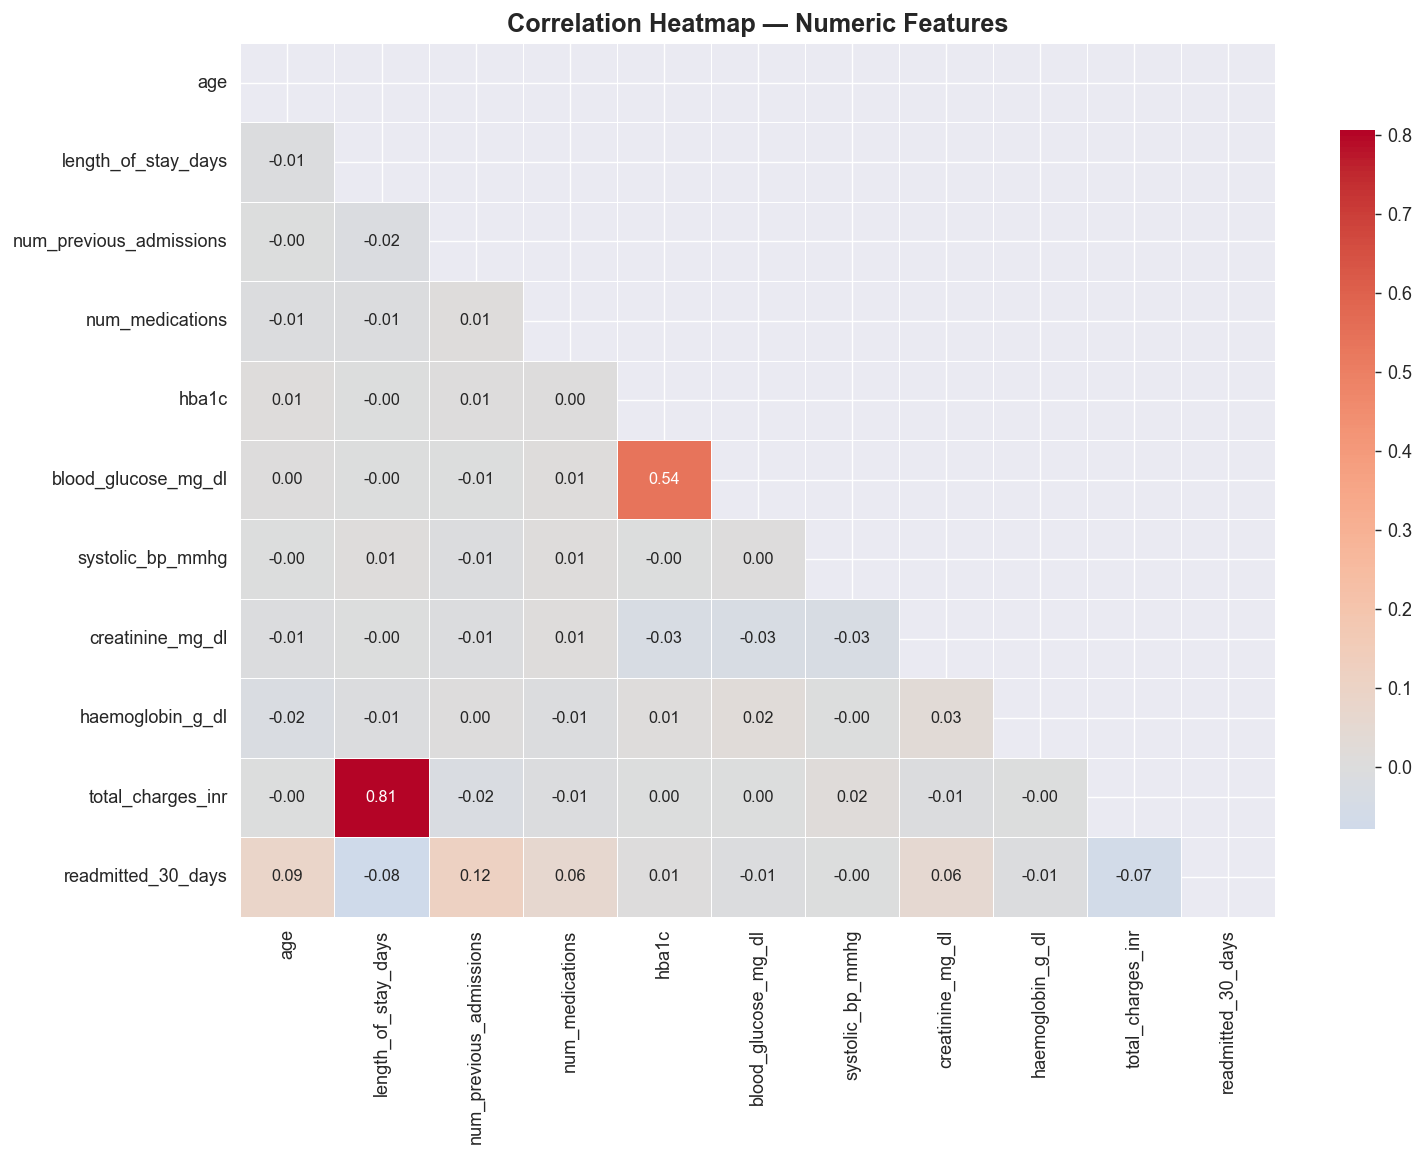


Top correlations with readmitted_30_days:
  num_previous_admissions             +0.121
  age                                 +0.085
  length_of_stay_days                 -0.078
  total_charges_inr                   -0.067
  num_medications                     +0.063
  creatinine_mg_dl                    +0.056
  haemoglobin_g_dl                    -0.008
  blood_glucose_mg_dl                 -0.007
  hba1c                               +0.006
  systolic_bp_mmhg                    -0.004


In [91]:
numeric_cols = [
    "age", "length_of_stay_days", "num_previous_admissions",
    "num_medications", "hba1c", "blood_glucose_mg_dl",
    "systolic_bp_mmhg", "creatinine_mg_dl",
    "haemoglobin_g_dl", "total_charges_inr", "readmitted_30_days"
]
 
corr = df[numeric_cols].corr()
 
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9})
plt.title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "09_correlation_heatmap.png"), bbox_inches="tight")
plt.show()
 
print("\nTop correlations with readmitted_30_days:")
corr_target = corr["readmitted_30_days"].drop("readmitted_30_days").sort_values(key=abs, ascending=False)
for col, val in corr_target.items():
    print(f"  {col:<35} {val:+.3f}")
 

In [93]:
print("=" * 65)
print("KEY INSIGHTS FROM EDA")
print("=" * 65)
 
insights = [
    f"Overall readmission rate              : {df['readmitted_30_days'].mean():.1%}",
    f"Highest risk diagnosis (CKD)          : {df[df['diagnosis']=='Chronic Kidney Disease']['readmitted_30_days'].mean():.1%}",
    f"Highest risk discharge type           : {df.groupby('discharge_type')['readmitted_30_days'].mean().idxmax()}",
    f"Short stay (≤2 days) readmission rate : {df[df['length_of_stay_days']<=2]['readmitted_30_days'].mean():.1%}",
    f"Long stay (>10 days) readmission rate : {df[df['length_of_stay_days']>10]['readmitted_30_days'].mean():.1%}",
    f"Age 65+ readmission rate              : {df[df['age']>=65]['readmitted_30_days'].mean():.1%}",
    f"8+ medications readmission rate       : {df[df['num_medications']>=8]['readmitted_30_days'].mean():.1%}",
    f"4+ prev admissions readmission rate   : {df[df['num_previous_admissions']>=4]['readmitted_30_days'].mean():.1%}",
    f"No insurance readmission rate         : {df[df['insurance_type']=='None (Self-pay)']['readmitted_30_days'].mean():.1%}",
    f"Diabetic + HbA1c>9 readmission rate   : {df[(df['diagnosis']=='Type 2 Diabetes')&(df['hba1c']>9)]['readmitted_30_days'].mean():.1%}",
    f"Avg charges readmitted (₹)            : ₹{df[df['readmitted_30_days']==1]['total_charges_inr'].mean():,.0f}",
    f"Avg charges not readmitted (₹)        : ₹{df[df['readmitted_30_days']==0]['total_charges_inr'].mean():,.0f}",
]
 
for i, insight in enumerate(insights, 1):
    print(f"  {i:>2}. {insight}")
 
print("=" * 65)
print("\nEDA Complete — Ready for Feature Engineering (Notebook 02)")
print("Charts saved to reports/")

KEY INSIGHTS FROM EDA
   1. Overall readmission rate              : 32.2%
   2. Highest risk diagnosis (CKD)          : 46.7%
   3. Highest risk discharge type           : Against Medical Advice
   4. Short stay (≤2 days) readmission rate : 37.7%
   5. Long stay (>10 days) readmission rate : 27.7%
   6. Age 65+ readmission rate              : 39.3%
   7. 8+ medications readmission rate       : 36.4%
   8. 4+ prev admissions readmission rate   : 52.0%
   9. No insurance readmission rate         : 30.8%
  10. Diabetic + HbA1c>9 readmission rate   : 45.0%
  11. Avg charges readmitted (₹)            : ₹47,473
  12. Avg charges not readmitted (₹)        : ₹51,678

EDA Complete — Ready for Feature Engineering (Notebook 02)
Charts saved to reports/
